##Problem Statement:
Build a Machine Learning model to predict whether a customer will purchase a product or not based on their browsing behavior and profile.

##Import the Libraries:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [ ]:
df=pd.read_csv("/content/ecommerce_customer_purchase.csv")

In [ ]:

df

,Age,Gender,Location,Device_Type,Time_Spent,Pages_Visited,Product_Category,Previous_Purchases,Avg_Order_Value,Discount,Purchase
0,56.0,Male,Bangalore,Desktop,8.375674,11.0,Beauty,3.0,1130.314296,27.665736,1.0
1,46.0,Female,Pune,Mobile,6.711783,8.0,Clothing,2.0,2095.949667,31.800461,1.0
2,32.0,Male,Bangalore,Desktop,8.366893,11.0,Clothing,3.0,1975.007914,6.534178,1.0
3,25.0,Male,Mumbai,Mobile,9.629894,12.0,NaN,6.0,1621.502361,4.172523,1.0
4,38.0,Male,Delhi,Tablet,8.146580,8.0,Electronics,6.0,733.649720,5.820619,1.0
...,...,...,...,...,...,...,...,...,...,...,...
495,NaN,Female,Hyderabad,Mobile,13.816787,19.0,Clothing,2.0,NaN,5.156103,1.0
496,49.0,Female,Mumbai,Tablet,4.999006,4.0,Clothing,2.0,628.889154,28.799872,1.0
497,41.0,Male,Bangalore,Mobile,5.966765,6.0,Beauty,3.0,1226.979101,4.046625,1.0
498,40.0,Male,Mumbai,Desktop,9.541724,9.0,Groceries,5.0,953.939400,24.925514,1.0


##EDA

In [ ]:
df.head()

,Age,Gender,Location,Device_Type,Time_Spent,Pages_Visited,Product_Category,Previous_Purchases,Avg_Order_Value,Discount,Purchase
0,56.0,Male,Bangalore,Desktop,8.375674,11.0,Beauty,3.0,1130.314296,27.665736,1.0
1,46.0,Female,Pune,Mobile,6.711783,8.0,Clothing,2.0,2095.949667,31.800461,1.0
2,32.0,Male,Bangalore,Desktop,8.366893,11.0,Clothing,3.0,1975.007914,6.534178,1.0
3,25.0,Male,Mumbai,Mobile,9.629894,12.0,NaN,6.0,1621.502361,4.172523,1.0
4,38.0,Male,Delhi,Tablet,8.146580,8.0,Electronics,6.0,733.649720,5.820619,1.0


it shows us top5 rows of the dataset.

In [ ]:
df.tail()

,Age,Gender,Location,Device_Type,Time_Spent,Pages_Visited,Product_Category,Previous_Purchases,Avg_Order_Value,Discount,Purchase
495,NaN,Female,Hyderabad,Mobile,13.816787,19.0,Clothing,2.0,NaN,5.156103,1.0
496,49.0,Female,Mumbai,Tablet,4.999006,4.0,Clothing,2.0,628.889154,28.799872,1.0
497,41.0,Male,Bangalore,Mobile,5.966765,6.0,Beauty,3.0,1226.979101,4.046625,1.0
498,40.0,Male,Mumbai,Desktop,9.541724,9.0,Groceries,5.0,953.939400,24.925514,1.0
499,49.0,NaN,Delhi,Mobile,8.538745,6.0,Clothing,3.0,1567.669174,14.242692,1.0


It shows us bottom 5 rows

In [ ]:
df.shape

(500, 11)

It describes number of rows and columns.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 475 non-null    float64
 1   Gender              475 non-null    object 
 2   Location            475 non-null    object 
 3   Device_Type         475 non-null    object 
 4   Time_Spent          475 non-null    float64
 5   Pages_Visited       475 non-null    float64
 6   Product_Category    475 non-null    object 
 7   Previous_Purchases  475 non-null    float64
 8   Avg_Order_Value     475 non-null    float64
 9   Discount            475 non-null    float64
 10  Purchase            475 non-null    float64
dtypes: float64(7), object(4)
memory usage: 43.1+ KB


It gives information about the dataset.

In [ ]:
df.describe()

,Age,Time_Spent,Pages_Visited,Previous_Purchases,Avg_Order_Value,Discount,Purchase
count,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.0
mean,39.250526,8.544961,8.810526,2.945263,1523.107706,20.225458,1.0
std,12.189017,4.146555,3.694833,1.608638,757.861890,11.826229,0.0
min,18.000000,1.000000,0.000000,0.000000,200.000000,0.283673,1.0
25%,29.000000,6.188259,6.000000,2.000000,1145.824584,9.735895,1.0
50%,41.000000,8.200972,9.000000,3.000000,1476.314649,20.734619,1.0
75%,50.000000,10.268745,11.000000,4.000000,1800.274283,30.380235,1.0
max,59.000000,47.945391,21.000000,9.000000,8357.025380,39.974012,1.0


It describes about the dataset.

There are no unique columns in the dataset

In [ ]:
## Handle null values

df.isnull().sum()


,0
Age,25
Gender,25
Location,25
Device_Type,25
Time_Spent,25
Pages_Visited,25
Product_Category,25
Previous_Purchases,25
Avg_Order_Value,25
Discount,25


In [ ]:
df_drop = df.dropna()

In [ ]:
#separate column types:
# Numerical columns
num_cols = ['Age', 'Time_Spent', 'Pages_Visited', 'Previous_Purchases', 'Avg_Order_Value', 'Discount']

# Categorical columns
cat_cols = ['Gender', 'Location', 'Device_Type', 'Product_Category']

In [ ]:
df['Time_Spent'].fillna(df['Time_Spent'].mean(), inplace=True)
df['Avg_Order_Value'].fillna(df['Avg_Order_Value'].mean(), inplace=True)
df['Discount'].fillna(df['Discount'].mean(), inplace=True)

In [ ]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Pages_Visited'].fillna(df['Pages_Visited'].median(), inplace=True)
df['Previous_Purchases'].fillna(df['Previous_Purchases'].median(), inplace=True)

In [ ]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [ ]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [ ]:
df['Purchase'].fillna(df['Purchase'].mode()[0], inplace=True)

In [ ]:
print(df.isnull().sum())

Age                   0
Gender                0
Location              0
Device_Type           0
Time_Spent            0
Pages_Visited         0
Product_Category      0
Previous_Purchases    0
Avg_Order_Value       0
Discount              0
Purchase              0
dtype: int64


In [ ]:
#Duplicate Check
df.duplicated().sum()

np.int64(0)

There are  no duplicates.

##Split the dataset into categorical and numerical column

In [ ]:
from pandas.core.arrays import categorical
## Divide the columns based on the data type

categorical_columns = df.select_dtypes(include=["object"])
numerical_columns = df.select_dtypes(exclude=["object"])

In [ ]:
categorical_columns

,Gender,Location,Device_Type,Product_Category
0,Male,Bangalore,Desktop,Beauty
1,Female,Pune,Mobile,Clothing
2,Male,Bangalore,Desktop,Clothing
3,Male,Mumbai,Mobile,Electronics
4,Male,Delhi,Tablet,Electronics
...,...,...,...,...
495,Female,Hyderabad,Mobile,Clothing
496,Female,Mumbai,Tablet,Clothing
497,Male,Bangalore,Mobile,Beauty
498,Male,Mumbai,Desktop,Groceries


In [ ]:
numerical_columns

,Age,Time_Spent,Pages_Visited,Previous_Purchases,Avg_Order_Value,Discount,Purchase
0,56.0,8.375674,11.0,3.0,1130.314296,27.665736,1.0
1,46.0,6.711783,8.0,2.0,2095.949667,31.800461,1.0
2,32.0,8.366893,11.0,3.0,1975.007914,6.534178,1.0
3,25.0,9.629894,12.0,6.0,1621.502361,4.172523,1.0
4,38.0,8.146580,8.0,6.0,733.649720,5.820619,1.0
...,...,...,...,...,...,...,...
495,41.0,13.816787,19.0,2.0,1523.107706,5.156103,1.0
496,49.0,4.999006,4.0,2.0,628.889154,28.799872,1.0
497,41.0,5.966765,6.0,3.0,1226.979101,4.046625,1.0
498,40.0,9.541724,9.0,5.0,953.939400,24.925514,1.0


In [ ]:
for i in categorical_columns:
  print(df[i].value_counts())

Gender
Male      278
Female    222
Name: count, dtype: int64
Location
Pune         126
Delhi        100
Mumbai        98
Hyderabad     92
Bangalore     84
Name: count, dtype: int64
Device_Type
Mobile     291
Desktop    162
Tablet      47
Name: count, dtype: int64
Product_Category
Electronics    146
Beauty         120
Groceries      118
Clothing       116
Name: count, dtype: int64


The value counts gets display

##Check for error values:

In [ ]:
df.replace(["?", "/", "unknown", "Unknown", "NA", "N/A"], np.nan, inplace=True)

In [ ]:
print(df.isnull().sum())

Age                   0
Gender                0
Location              0
Device_Type           0
Time_Spent            0
Pages_Visited         0
Product_Category      0
Previous_Purchases    0
Avg_Order_Value       0
Discount              0
Purchase              0
dtype: int64


No errors found

#### Outlier detection

In [ ]:

def outlier_detection(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [ ]:
for col in numerical_columns:
  df = outlier_detection(df, col)

In [ ]:
df

,Age,Gender,Location,Device_Type,Time_Spent,Pages_Visited,Product_Category,Previous_Purchases,Avg_Order_Value,Discount,Purchase
0,56.0,Male,Bangalore,Desktop,8.375674,11.0,Beauty,3.0,1130.314296,27.665736,1.0
1,46.0,Female,Pune,Mobile,6.711783,8.0,Clothing,2.0,2095.949667,31.800461,1.0
2,32.0,Male,Bangalore,Desktop,8.366893,11.0,Clothing,3.0,1975.007914,6.534178,1.0
3,25.0,Male,Mumbai,Mobile,9.629894,12.0,Electronics,6.0,1621.502361,4.172523,1.0
4,38.0,Male,Delhi,Tablet,8.146580,8.0,Electronics,6.0,733.649720,5.820619,1.0
...,...,...,...,...,...,...,...,...,...,...,...
494,41.0,Female,Pune,Mobile,8.379139,8.0,Groceries,1.0,1163.757202,34.990642,1.0
496,49.0,Female,Mumbai,Tablet,4.999006,4.0,Clothing,2.0,628.889154,28.799872,1.0
497,41.0,Male,Bangalore,Mobile,5.966765,6.0,Beauty,3.0,1226.979101,4.046625,1.0
498,40.0,Male,Mumbai,Desktop,9.541724,9.0,Groceries,5.0,953.939400,24.925514,1.0


As outliers are found in the dataset ,so the outliers are removed and we can see that no. of rows has reduced.

## Univariate and Bivariate analysis

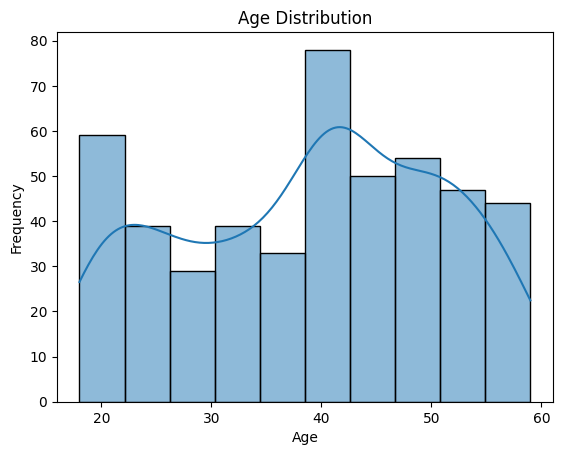

In [ ]:
#Age Distribution
plt.figure()
sns.histplot(df['Age'], bins=10, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

The Age feature shows a fairly uniform distribution between 18–60.No strong skewness or extreme values are found.It indicates balanced representation of different age groups.

####Time_Spent Distribution

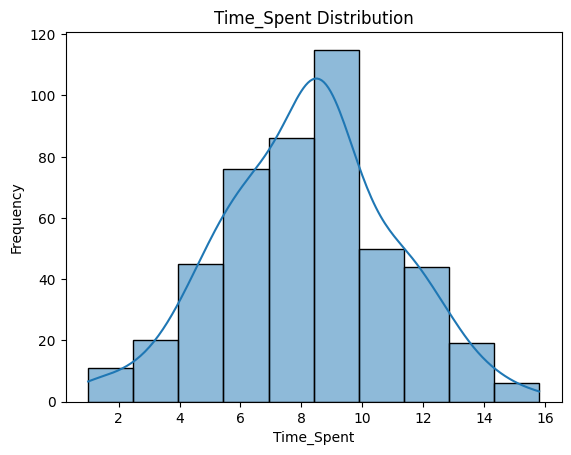

In [ ]:
plt.figure()
sns.histplot(df['Time_Spent'], bins=10, kde=True)
plt.title("Time_Spent Distribution")
plt.xlabel("Time_Spent")
plt.ylabel("Frequency")
plt.show()

Distribution is right-skewed (positively skewed)
Most users spend moderate time, few spend very high time.It shows presence of outliers (very high values)

####Pages_Visited Distribution

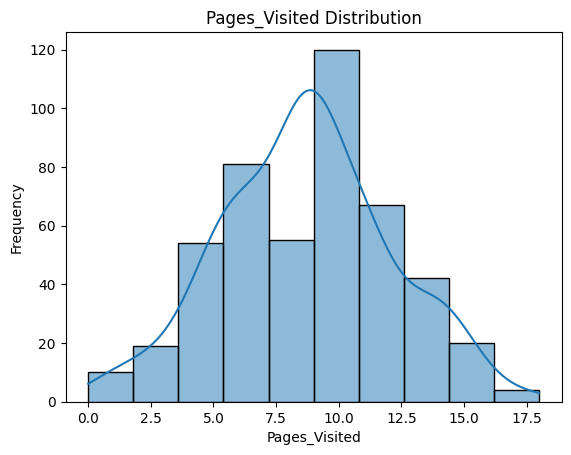

In [ ]:
plt.figure()
sns.histplot(df['Pages_Visited'], bins=10, kde=True)
plt.title("Pages_Visited Distribution")
plt.xlabel("Pages_Visited")
plt.ylabel("Frequency")
plt.show()

This graph shows a discrete distribution (count data).It is slight right skew.Majority users visit fewer pages.

####Previous_Purchases Distribution

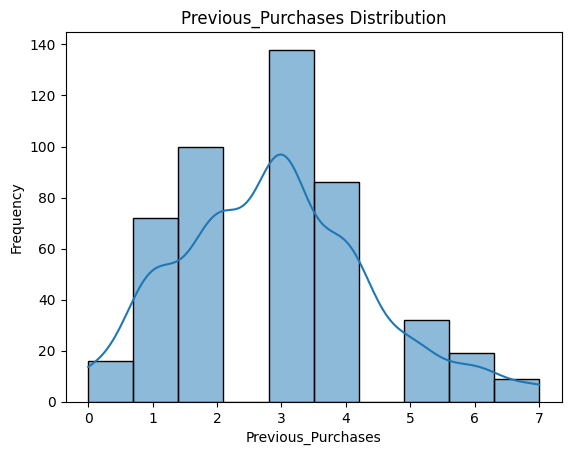

In [ ]:
plt.figure()
sns.histplot(df['Previous_Purchases'], bins=10, kde=True)
plt.title("Previous_Purchases Distribution")
plt.xlabel("Previous_Purchases")
plt.ylabel("Frequency")
plt.show()

This graph has Highly right-skewed distribution.Most customers have few purchases,we can see in the histplot.Few customers have high purchase counts.

####Avg_Order_Value Distribution

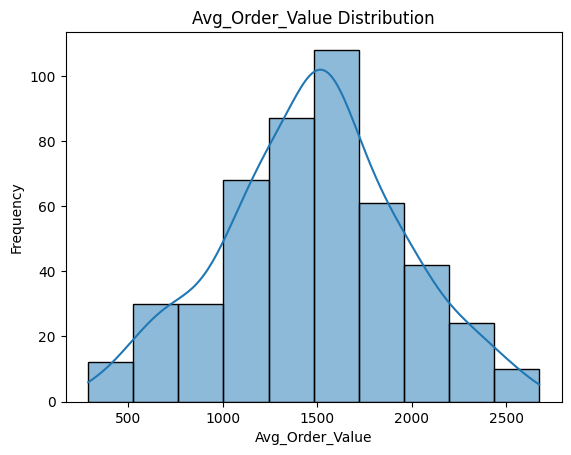

In [ ]:
plt.figure()
sns.histplot(df['Avg_Order_Value'], bins=10, kde=True)
plt.title("Avg_Order_Value Distribution")
plt.xlabel("Avg_Order_Value")
plt.ylabel("Frequency")
plt.show()

It is Strong right skewness.Extreme high-value outliers are present.Majority orders are in lower price range.

####Discount Distribution

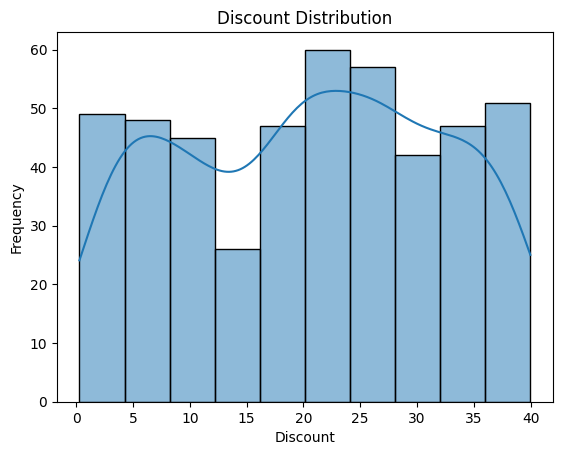

In [ ]:
plt.figure()
sns.histplot(df['Discount'], bins=10, kde=True)
plt.title("Discount Distribution")
plt.xlabel("Discount")
plt.ylabel("Frequency")
plt.show()

Distribution is almost uniform.Values spread evenly across range

####Categorical columns gender count

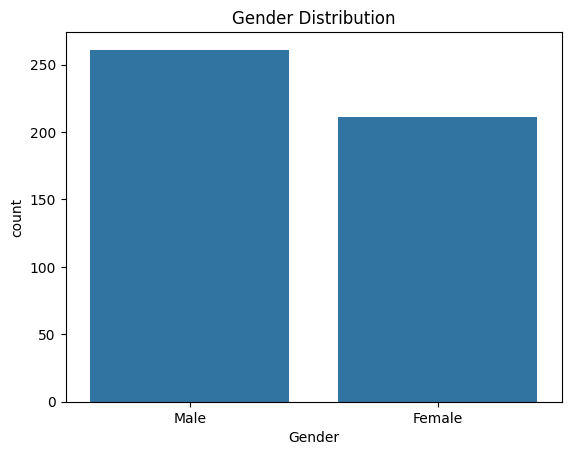

In [ ]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

The graph displays number of Male vs Female customers(count)Usually nearly balanced.

Categorical columns Location count

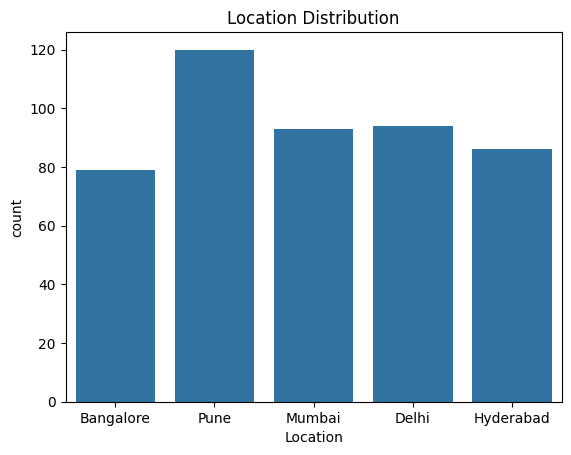

In [ ]:
sns.countplot(x='Location', data=df)
plt.title("Location Distribution")
plt.show()

This graph shows Number of customers from each city.Pune is the dominating city in this graph.

Categorical columns Device_Type count

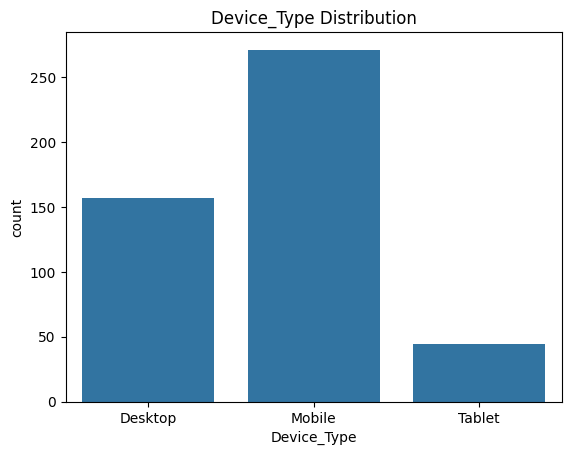

In [ ]:
sns.countplot(x='Device_Type', data=df)
plt.title("Device_Type Distribution")
plt.show()

Distribution of Mobile, Desktop, Tablet users is shown.
Mobile is  usually highest

Categorical columns Product category count

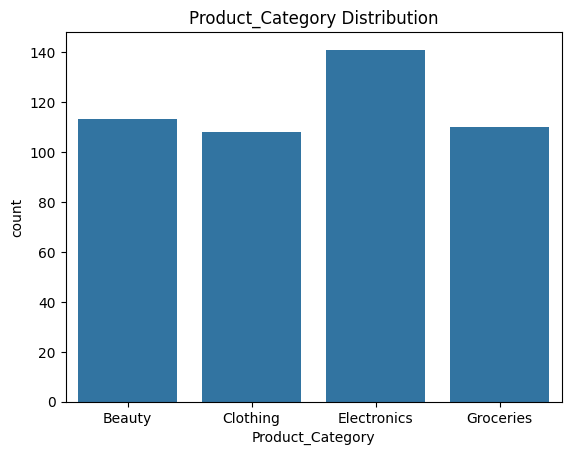

In [ ]:
sns.countplot(x='Product_Category', data=df)
plt.title("Product_Category Distribution")
plt.show()

Number of views per product category is shown.Some categories more popular

Purchase (Target) count polt

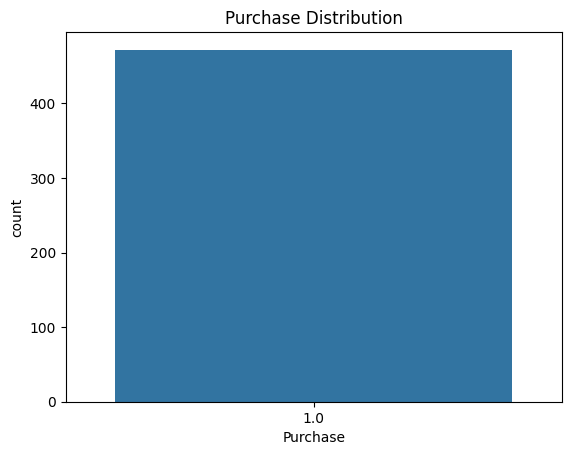

In [ ]:
sns.countplot(x='Purchase', data=df)
plt.title("Purchase Distribution")
plt.show()

Number of customers who:
0 → Did not purchase
1 → Purchased

##Bivariate Analysis:

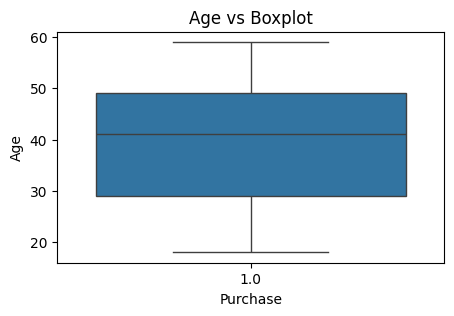

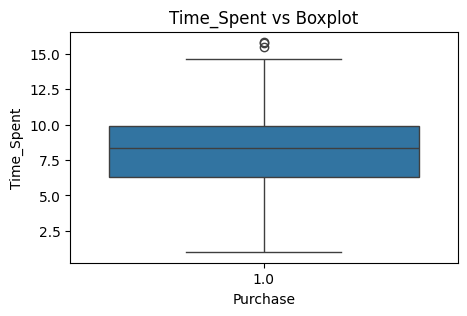

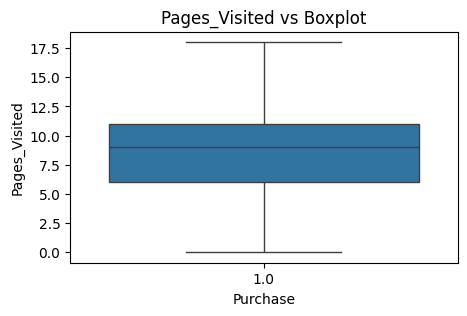

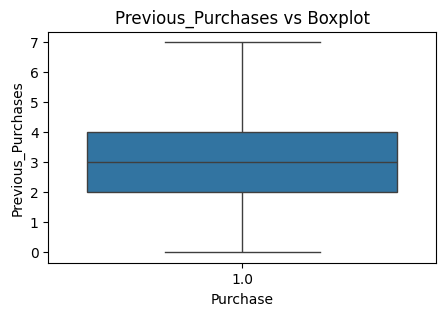

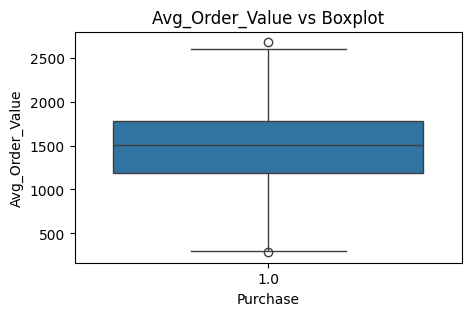

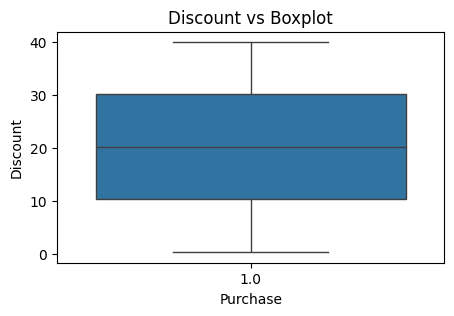

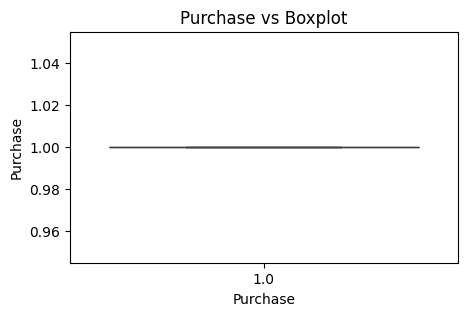

In [ ]:
for col in numerical_columns:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df['Purchase'], y=df[col])
    plt.title(f"{col} vs Boxplot")
    plt.show()

Box plots show the relationship between numerical features and the target variable. Features like Time_Spent, Pages_Visited, and Previous_Purchases show a clear difference between buyers and non-buyers, indicating strong influence on purchase behavior.

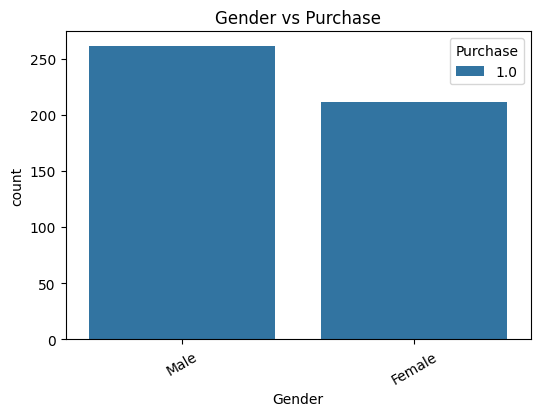

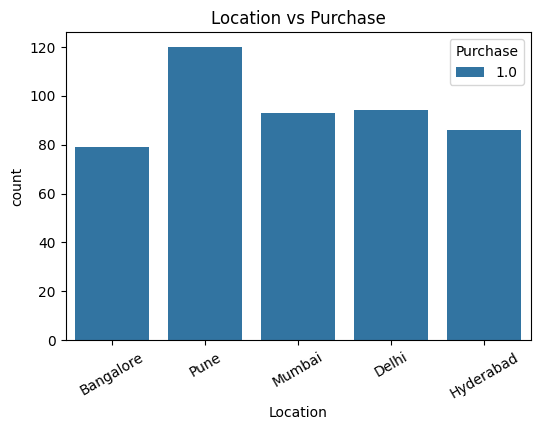

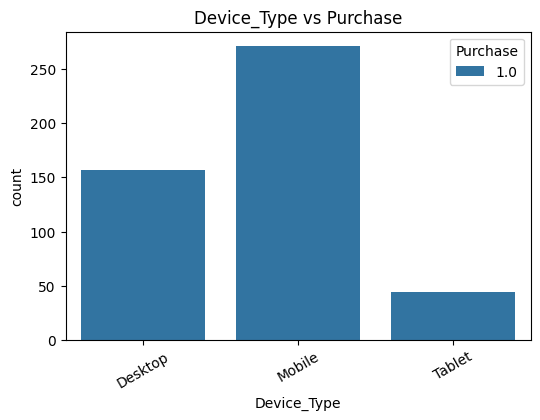

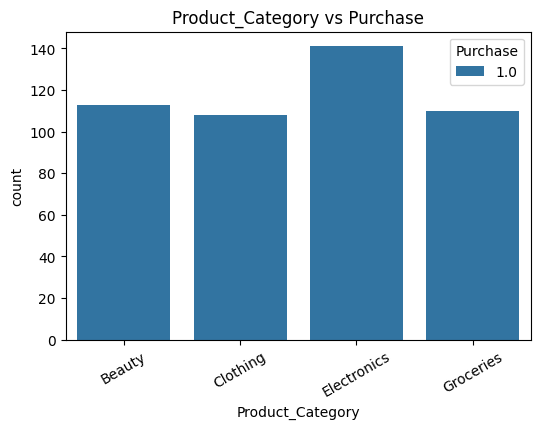

In [ ]:
for col in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col], hue=df['Purchase'])
    plt.title(f"{col} vs Purchase")
    plt.xticks(rotation=30)
    plt.show()

Bivariate count plots are used to analyze the relationship between categorical features and the target variable. By using hue as Purchase, we can compare how different categories influence buying behavior and identify trends such as high-performing locations or product categories

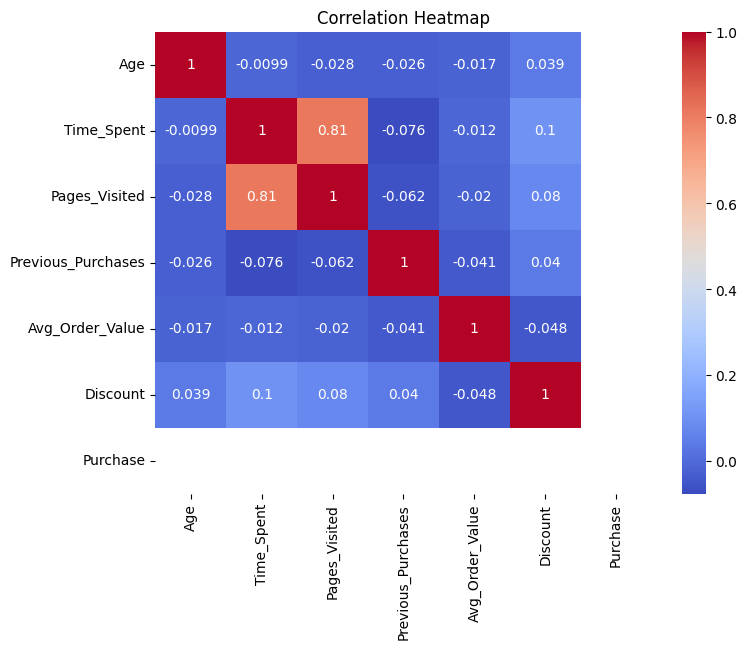

In [ ]:
#corelation heatmap
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Correlation heatmap shows the strength and direction of relationships between numerical features. In this dataset, Time_Spent and Pages_Visited are highly correlated, while Previous_Purchases and Discount show positive correlation with the target variable. Age has very low correlation, indicating weak predictive power.

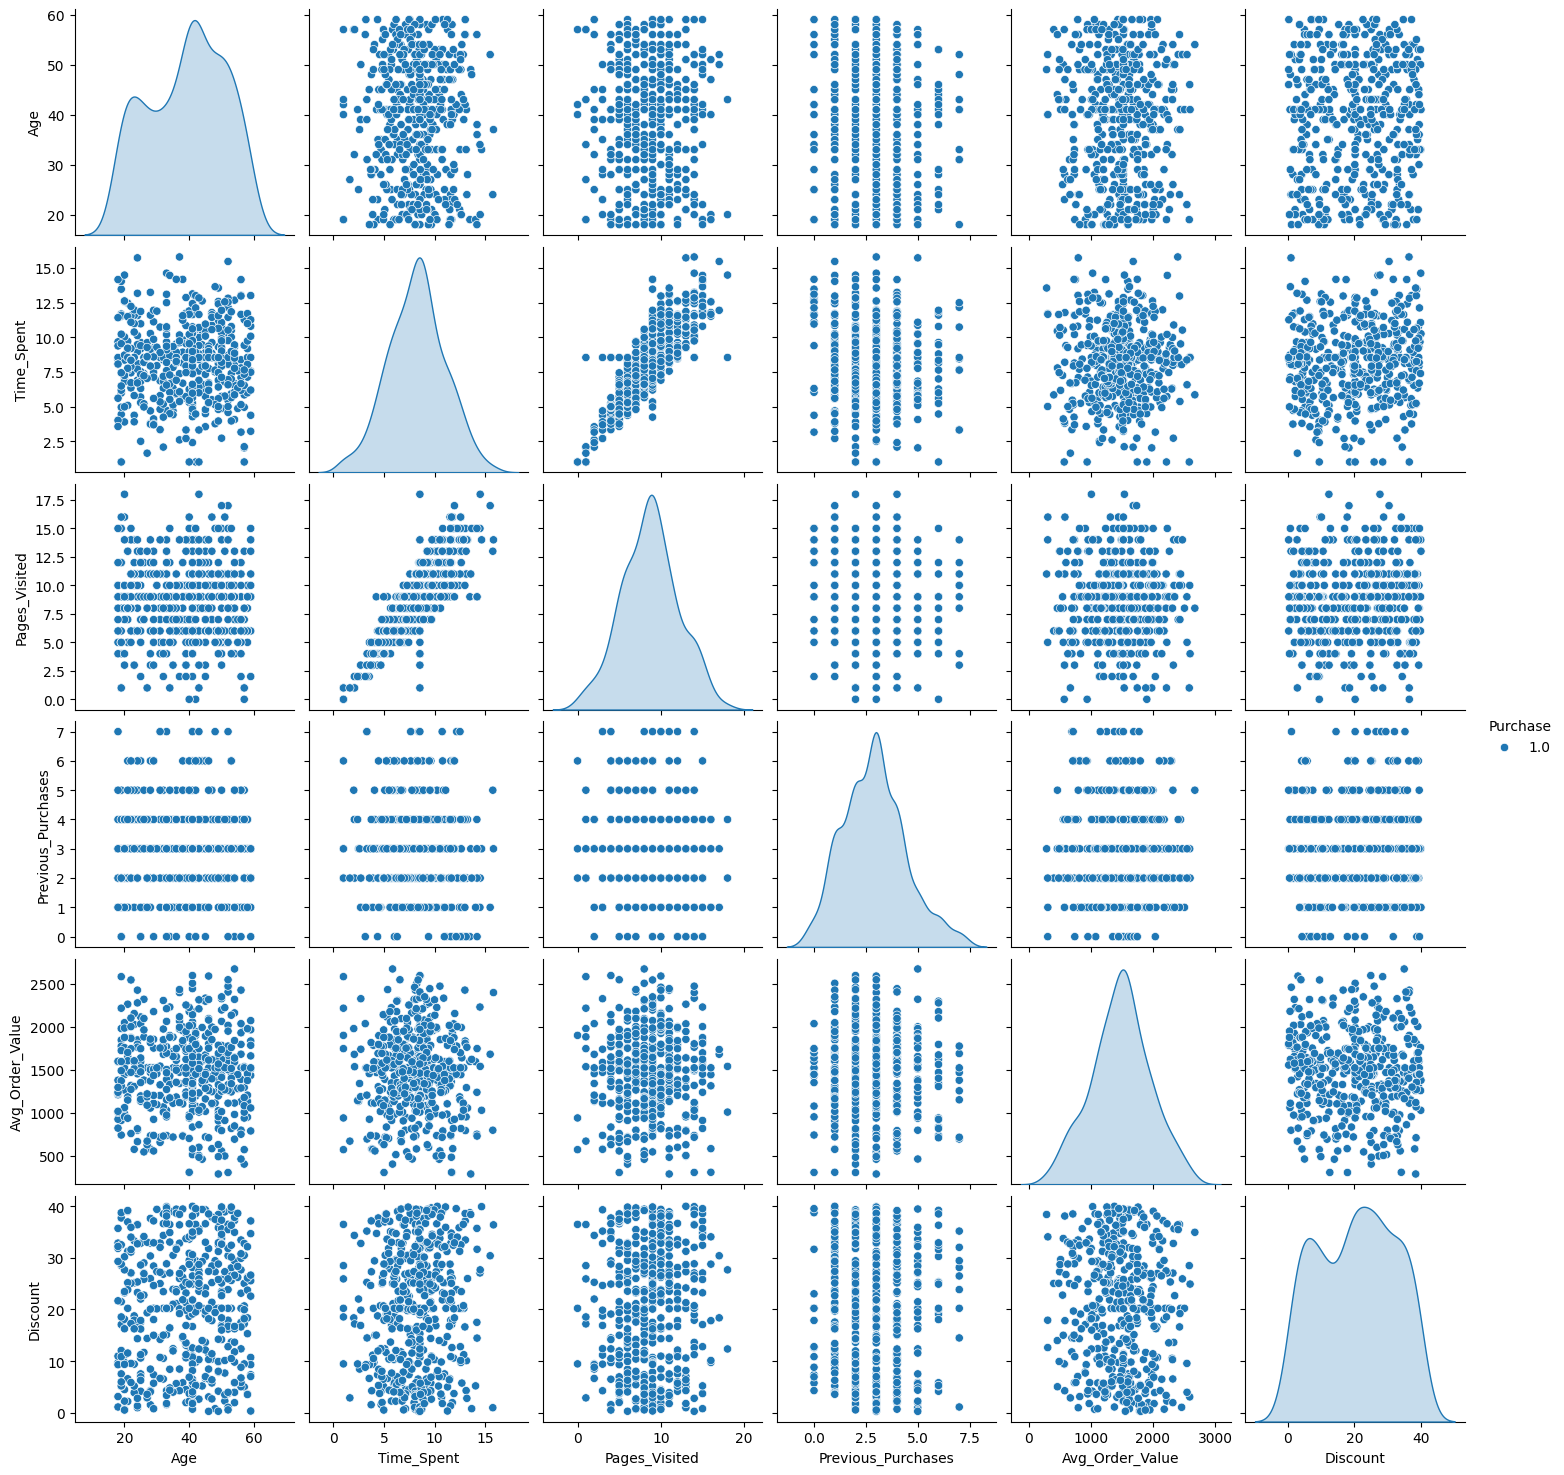

In [ ]:
# Pairplot
sns.pairplot(df, hue='Purchase')

plt.show()


Pairplot visualizes relationships between all numerical features and helps identify correlations, class separation, and outliers. In this dataset, Time_Spent and Pages_Visited show strong correlation, while features like Previous_Purchases and Discount help distinguish between purchase and non-purchase behavior.


In [ ]:
categorical_columns

,Gender,Location,Device_Type,Product_Category
0,Male,Bangalore,Desktop,Beauty
1,Female,Pune,Mobile,Clothing
2,Male,Bangalore,Desktop,Clothing
3,Male,Mumbai,Mobile,Electronics
4,Male,Delhi,Tablet,Electronics
...,...,...,...,...
495,Female,Hyderabad,Mobile,Clothing
496,Female,Mumbai,Tablet,Clothing
497,Male,Bangalore,Mobile,Beauty
498,Male,Mumbai,Desktop,Groceries


In [ ]:
## Encoding

from sklearn.preprocessing import LabelEncoder

In [ ]:
le_d = {}

In [ ]:
for col in categorical_columns:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])  ## It will convert all the categorical data to numerical data
  le_d[col] = le  ## Saving the encoding for future use

In [ ]:
le_d

{'Gender': LabelEncoder(),
 'Location': LabelEncoder(),
 'Device_Type': LabelEncoder(),
 'Product_Category': LabelEncoder()}

In [ ]:
df

,Age,Gender,Location,Device_Type,Time_Spent,Pages_Visited,Product_Category,Previous_Purchases,Avg_Order_Value,Discount,Purchase
0,56.0,1,0,0,8.375674,11.0,0,3.0,1130.314296,27.665736,1.0
1,46.0,0,4,1,6.711783,8.0,1,2.0,2095.949667,31.800461,1.0
2,32.0,1,0,0,8.366893,11.0,1,3.0,1975.007914,6.534178,1.0
3,25.0,1,3,1,9.629894,12.0,2,6.0,1621.502361,4.172523,1.0
4,38.0,1,1,2,8.146580,8.0,2,6.0,733.649720,5.820619,1.0
...,...,...,...,...,...,...,...,...,...,...,...
494,41.0,0,4,1,8.379139,8.0,3,1.0,1163.757202,34.990642,1.0
496,49.0,0,3,2,4.999006,4.0,1,2.0,628.889154,28.799872,1.0
497,41.0,1,0,1,5.966765,6.0,0,3.0,1226.979101,4.046625,1.0
498,40.0,1,3,0,9.541724,9.0,3,5.0,953.939400,24.925514,1.0


It converts male as 1 and female as 0.In such ways it converts categorical columns to numerical columns.

In [ ]:
#Ordinal Encoding
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
oe = OrdinalEncoder()

In [ ]:
df[['Product_Category']] = oe.fit_transform(df[['Product_Category']])

In [ ]:
# One Hot Encoding
df = pd.get_dummies(df, columns=categorical_columns.columns, drop_first=True)

Encoding converts categorical data into numerical form so ML models can process it. One-hot encoding is preferred for nominal data, while ordinal encoding is used when categories have a meaningful order.

##Model Building

In [ ]:
X = df.drop('Purchase', axis=1)
y = df['Purchase']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.8)

In [ ]:
display((X_train.shape, X_test.shape, y_train.shape, y_test.shape))

((377, 16), (95, 16), (377,), (95,))

In [ ]:
## Importing multiple models

from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [ ]:
nb = GaussianNB()
rf = RandomForestClassifier()
dt = DecisionTreeClassifier()

In [ ]:
## Training the model

nb.fit(X_train, y_train)
rf.fit(X_train, y_train)
dt.fit(X_train, y_train)

DecisionTreeClassifier()

Model training is performed,where the model learns patterns from input features and their corresponding target values.

In [ ]:
## Model evaluation

nb_pred = nb.predict(X_test)
rf_pred = rf.predict(X_test)
dt_pred = dt.predict(X_test)

In [ ]:
## Confusion matrix print for all

print("Confusion matrix for Naive Bayes")
print(metrics.confusion_matrix(y_test, nb_pred))

Confusion matrix for Naive Bayes
[[95]]


In [ ]:
print("Confusion matrix for Random Forest")
print(metrics.confusion_matrix(y_test, rf_pred))

Confusion matrix for Random Forest
[[95]]


In [ ]:
print("Confusion matrix for Decision Tree")
print(metrics.confusion_matrix(y_test, dt_pred))

Confusion matrix for Decision Tree
[[95]]


In [ ]:
nb_acc = metrics.accuracy_score(y_test, nb_pred)
rf_acc = metrics.accuracy_score(y_test, rf_pred)
dt_acc = metrics.accuracy_score(y_test, dt_pred)

In [ ]:
print("Accuracy for Naive Bayes: ", nb_acc)
print("Accuracy for Random Forest: ", rf_acc)
print("Accuracy for Decision Tree: ", dt_acc)

Accuracy for Naive Bayes:  1.0
Accuracy for Random Forest:  1.0
Accuracy for Decision Tree:  1.0


In [ ]:
from sklearn.metrics import precision_score, recall_score
precision = precision_score(y_test, nb_pred)
print("Precision:", precision)

Precision: 1.0


In [ ]:
recall = recall_score(y_test, nb_pred)
print("Recall:", recall)

Recall: 1.0


Model performance is evaluated using confusion matrix, accuracy, precision, recall, and misclassification rate. These metrics help in understanding how well the model predicts both positive and negative classes

##GridsearchCV :

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error, mean_absolute_error

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [ ]:
#Initialze the GridSearch

grid = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5)

In [ ]:
#Train the GridSearch

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]})

In [ ]:
print("Best parameters found by GridSearchCV:")
print(grid.best_params_)

Best parameters found by GridSearchCV:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
print("Best CV score: ",grid.best_score_)

Best CV score:  1.0


In [ ]:
best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test)

In [ ]:
print("R2 Score:", r2_score(y_test, y_pred_tuned))
print("MSE:", mean_squared_error(y_test, y_pred_tuned))
print("MAE:", mean_absolute_error(y_test, y_pred_tuned))

R2 Score: 1.0
MSE: 0.0
MAE: 0.0


In [ ]:
bl_y_pred = rf.predict(X_test)
print("Before Tuning:", r2_score(y_test, bl_y_pred))
print("After Tuning:", r2_score(y_test, y_pred_tuned))

Before Tuning: 1.0
After Tuning: 1.0
